In [2]:
import os
import pandas as pd
import numpy as np

In [3]:
# individual consumer data
consumers = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-consDF.pqt")
consumers.head()

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0


In [4]:
# account information
accounts = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-acctDF.pqt")
accounts.head()

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
0,3023,0,SAVINGS,2021-08-31,90.57
1,3023,1,CHECKING,2021-08-31,225.95
2,4416,2,SAVINGS,2022-03-31,15157.17
3,4416,3,CHECKING,2022-03-31,66.42
4,4227,4,CHECKING,2021-07-31,7042.90


In [5]:
# transactional data
transactions = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-trxnDF.pqt")
transactions

,prism_consumer_id,prism_transaction_id,category,amount,credit_or_debit,posted_date
0,3023,0,4,0.05,CREDIT,2021-04-16
1,3023,1,12,481.56,CREDIT,2021-04-30
2,3023,2,4,0.05,CREDIT,2021-05-16
3,3023,3,4,0.07,CREDIT,2021-06-16
4,3023,4,4,0.06,CREDIT,2021-07-16
...,...,...,...,...,...,...
6407316,10533,6405304,31,4.96,DEBIT,2022-03-11
6407317,10533,6405305,12,63.48,DEBIT,2022-03-30
6407318,10533,6405306,12,53.99,DEBIT,2022-03-30
6407319,10533,6405307,12,175.98,DEBIT,2022-03-31


# Target Distribution Comparison

In [34]:
# merge df to get balance with consumer id
merged_df = consumers.merge(
    accounts,
    on="prism_consumer_id",
    how="inner"
)[[
    "prism_consumer_id",
    "credit_score",
    "DQ_TARGET",
    "account_type",
    "balance_date",
    "balance"
]]

merged_df.head()

,prism_consumer_id,credit_score,DQ_TARGET,account_type,balance_date,balance
0,0,726.0,0.0,SAVINGS,2021-08-31,25.70
1,0,726.0,0.0,CHECKING,2021-08-31,294.67
2,1,626.0,0.0,SAVINGS,2021-06-30,3211.18
3,1,626.0,0.0,CHECKING,2021-06-30,91.24
4,2,680.0,0.0,SAVINGS,2021-04-30,2561.43


In [35]:
# set datetime index and remove na values
merged_df = merged_df.dropna(subset=["balance_date", "DQ_TARGET", "balance"])
merged_df["balance_date"] = pd.to_datetime(merged_df["balance_date"])

print(f'{merged_df.shape}')

(19487, 6)


In [50]:
# Build per-consumer per-date balance time series and sample GOODS_N + BADS_N consumers with >= MIN_POINTS history
import pandas as pd

GOODS_N = 3
BADS_N = 3
MIN_POINTS = 2

df = cleaned.copy()
df["balance_date"] = pd.to_datetime(df["balance_date"], errors="coerce")

daily = (
    df.dropna(subset=["prism_consumer_id", "balance_date", "balance", "DQ_TARGET"])
      .assign(DQ_TARGET=lambda x: x["DQ_TARGET"].astype(int))
      .groupby(["prism_consumer_id", "DQ_TARGET", "balance_date"], as_index=False)["balance"]
      .sum()
      .sort_values(["prism_consumer_id", "balance_date"])
)

eligible = daily.groupby(["prism_consumer_id", "DQ_TARGET"]).size().reset_index(name="n")
eligible = eligible[eligible["n"] >= MIN_POINTS]

goods_pool = eligible.loc[eligible["DQ_TARGET"] == 0, "prism_consumer_id"].unique()
bads_pool  = eligible.loc[eligible["DQ_TARGET"] == 1, "prism_consumer_id"].unique()

goods_ids = pd.Series(goods_pool).sample(n=min(GOODS_N, len(goods_pool))).tolist()
bads_ids  = pd.Series(bads_pool).sample(n=min(BADS_N, len(bads_pool))).tolist()

sample_daily_goods = daily[daily["prism_consumer_id"].isin(goods_ids)].copy()
sample_daily_bads  = daily[daily["prism_consumer_id"].isin(bads_ids)].copy()

print("goods_ids:", goods_ids)
print("bads_ids:", bads_ids)
print("goods lines:", sample_daily_goods["prism_consumer_id"].nunique(), "bads lines:", sample_daily_bads["prism_consumer_id"].nunique())

goods_ids: ['2935', '3558', '2381']
bads_ids: ['3541', '2334', '1147']
goods lines: 3 bads lines: 3


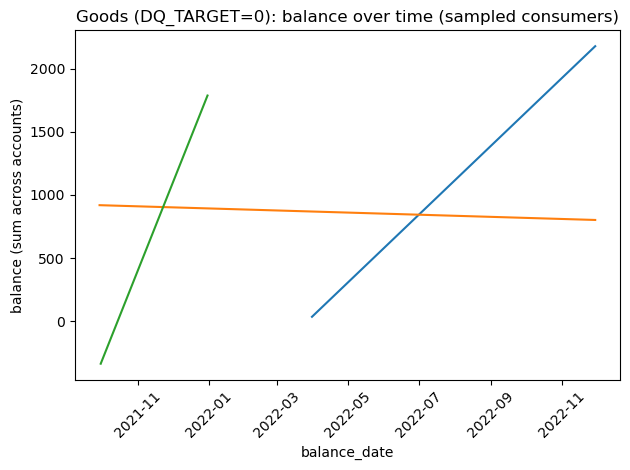

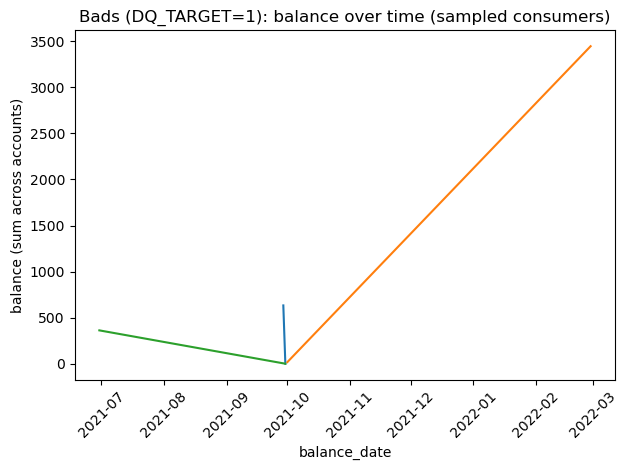

In [51]:
# Plot 2 graphs: goods vs bads (one line per consumer)
import matplotlib.pyplot as plt

g = sample_daily_goods.sort_values(["prism_consumer_id", "balance_date"])
b = sample_daily_bads.sort_values(["prism_consumer_id", "balance_date"])

plt.figure()
for cid, sub in g.groupby("prism_consumer_id"):
    plt.plot(sub["balance_date"], sub["balance"])
plt.xlabel("balance_date")
plt.ylabel("balance (sum across accounts)")
plt.title("Goods (DQ_TARGET=0): balance over time (sampled consumers)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
for cid, sub in b.groupby("prism_consumer_id"):
    plt.plot(sub["balance_date"], sub["balance"])
plt.xlabel("balance_date")
plt.ylabel("balance (sum across accounts)")
plt.title("Bads (DQ_TARGET=1): balance over time (sampled consumers)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
